Notebook to place a pattern on a FIB image

In [1]:
# general
from copy import deepcopy

# for display
import napari
import matplotlib.pyplot as plt
import tifffile
from matplotlib.backends.backend_agg import FigureCanvasAgg as FigureCanvas
import numpy as np

# for the fibsem structures
from fibsem.structures import FibsemImage
from fibsem.patterning import FibsemMillingStage, get_milling_stages, TrenchPattern
from fibsem.microscope import FibsemMicroscope
from fibsem.patterns.ui import draw_milling_patterns

# for drawing patterns
from fibsem.ui.utils import _draw_patterns_in_napari
from fibsem import milling

# Set up test microscope
from fibsem import utils, acquire

# Adaptive polishing
from adaptive_polish import gis_measurement as gm
gm.init_model_with_path(model_path=r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\2024-02-24_0013_gis_lamela_crack_pytorch_AUnet.ptchkp")

Default configuration: microscope-configuration-demo2
Default configuration path: C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2024\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml


c:\Users\dmv31621\AppData\Local\miniforge3\envs\adaptive_polish\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\dmv31621\AppData\Local\miniforge3\envs\adaptive_polish\lib\site-packages\albumentations\__init__.py:24: UserWarning: A new version of Albumentations is available: 1.4.24 (you have 1.4.23). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()
C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\dl_segmentation\sem_lamella_segmentor.py:121: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious

In [2]:
# Set up test microscope
config_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\fibsem\fibsem\config\microscope-configuration-demo2.yaml"
protocol_path = r"C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\scripts\spoof_microscope_protocol.yaml"
PIXEL_SIZE_M = 1.3020833333333335e-08 * 2  # actual images are 3072x2048 px but the config is set to half this size

microscope, settings = utils.setup_session(config_path=config_path, protocol_path=protocol_path)

2025-01-02 16:06:53,440 — root — INFO — connect_to_microscope:5403 — Microscope client connected to DemoMicroscope with serial number 123456 and software version 0.1
2025-01-02 16:06:53,441 — root — INFO — setup_session:218 — Finished setup for session: openfibsem_2025-01-02-04-06-53PM


In [3]:
# "Acquire" images
eb_image, ib_image = acquire.take_reference_images(microscope, settings.image)

2025-01-02 16:06:53,464 — root — INFO — acquire_image:6383 — acquiring new ELECTRON image.
2025-01-02 16:06:53,465 — root — INFO — acquire_image:6384 — resolution:[1536, 1024], hfw:4e-05
2025-01-02 16:06:53,467 — root — INFO — acquire_image:6391 — SEM
2025-01-02 16:06:53,468 — root — INFO — load:141 — Loading C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\2024segmentation_testdata\SEM\01A_SEM_mill.tif as spoof image
2025-01-02 16:06:57,848 — root — INFO — acquire_image:6418 — img_data.type:<class 'numpy.ndarray'>
2025-01-02 16:06:57,849 — root — INFO — acquire_image:6419 — img_data.dtype:uint8, img_data.shape:(2048, 3072)
2025-01-02 16:06:57,850 — root — INFO — acquire_image:6423 — demo image has shape:(2048, 3072). Resizing to (np.int64(1024), np.int64(1536))
2025-01-02 16:06:58,024 — root — INFO — acquire_image:6427 — Resized, img_data.dtype:uint8, img_data.shape:(1024, 1536)
2025-01-02 16:06:58,025 — root — INFO — acquire_image:6441 — data_uint

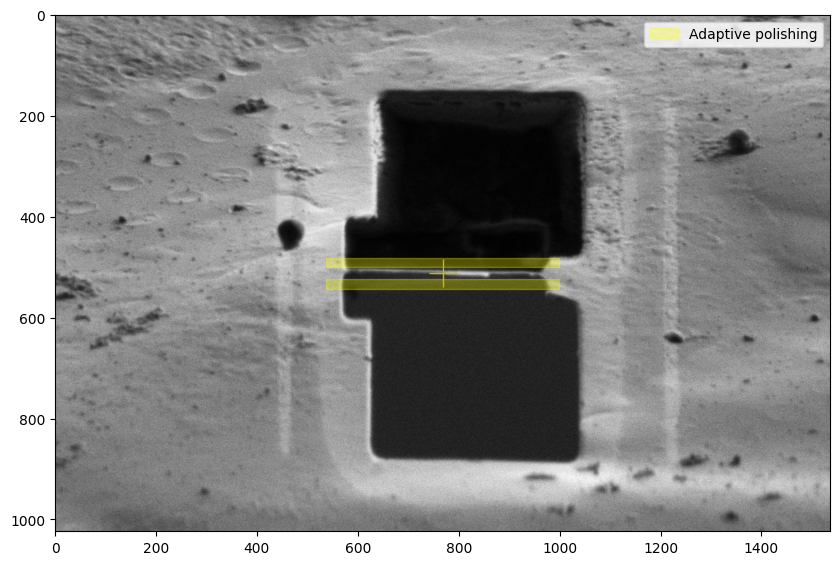

In [4]:
# Place pattern on FIB image from original protocol.yaml file
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

2025-01-02 16:07:03,156 — root — INFO — get_prepreds_tfms:59 — imgsize:(1024, 1536), new_size:[512, 768]
2025-01-02 16:07:03,182 — root — INFO — get_prediction:210 — data1.shape:torch.Size([1, 512, 768])
2025-01-02 16:07:03,594 — root — INFO — get_prediction:218 — pred0.shape:torch.Size([1, 4, 512, 768])
2025-01-02 16:07:03,617 — root — INFO — clean_prediction:91 — clean_prediction with prediction.shape:(1024, 1536), pixel_size_m:2.604166666666667e-08
2025-01-02 16:07:03,704 — root — INFO — measure_GIS:118 — window_size_px: 3
2025-01-02 16:07:03,707 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()
Lamella width is 9.401041666666667e-06 m


C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\gis_measurement.py:80: UserWarning: Only one label was provided to `remove_small_objects`. Did you mean to use a boolean array?
  mask_largest_only = skimage.morphology.remove_small_objects(
C:\Users\dmv31621\OneDrive - The Rosalind Franklin Institute\2025\00_Adaptive-milling\adaptive_polish\src\adaptive_polish\gis_measurement.py:148: RuntimeWarning: All-NaN slice encountered
  GIS_windowed = np.nanmedian(GIS_pxbypx_NaNed.reshape(-1, window_size_px), axis=1)


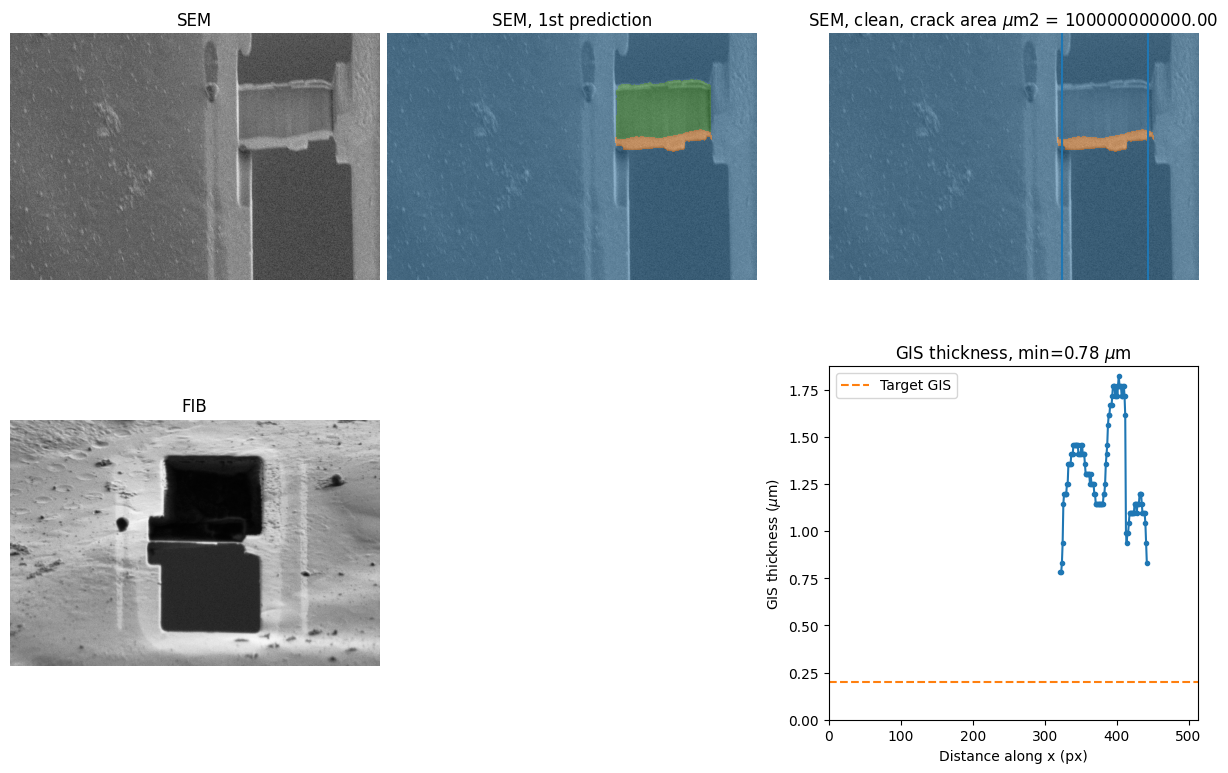

In [5]:
# Find the lamella width based on SEM image segmentation
prediction = gm.segment(eb_image.data)
clean_prediction = gm.clean_prediction(prediction=prediction, pixel_size_m=PIXEL_SIZE_M)
gis_thickness_m, xlims = gm.measure_GIS(mask_gis_clean=clean_prediction, window_size_m=1e-7, pixel_size_m=PIXEL_SIZE_M)
gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=2e-7,
    crack_area_m2=0.1,
    xlims=xlims,
    fib_screenshot=None,  # need to figure out how to pass this to plot,
    )
lamella_width = (xlims[1] - xlims[0]) * PIXEL_SIZE_M
print(f"Lamella width is {lamella_width} m")

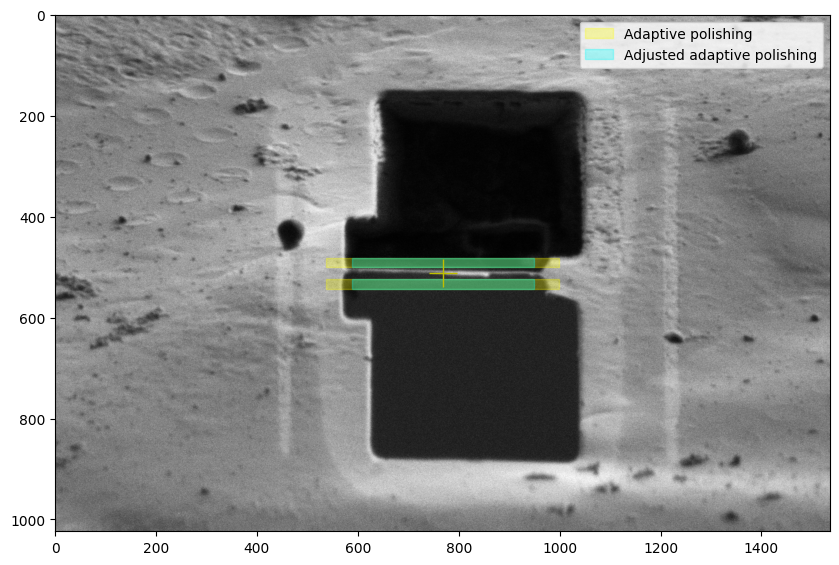

In [6]:
# Place pattern on image from edited pattern
ap_milling_protocol = deepcopy(settings.protocol["milling"]["lamella"]["stages"][-1])
ap_milling_protocol["lamella_width"] = lamella_width
ap_milling_protocol["hfw"] = 4e-05
ap_milling_protocol["trench_height"] = 5e-7
ap_milling_protocol["name"] = "Adjusted adaptive polishing"
if settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"].append(ap_milling_protocol)
elif settings.protocol["milling"]["lamella"]["stages"][-1]["name"] == "Adjusted adaptive polishing":
    settings.protocol["milling"]["lamella"]["stages"][-1] = ap_milling_protocol
stages = get_milling_stages("lamella", settings.protocol["milling"])
fig = draw_milling_patterns(ib_image, stages)

2025-01-02 16:07:05,805 — root — INFO — milling_cycle_plot:201 — milling_cycle_plot()


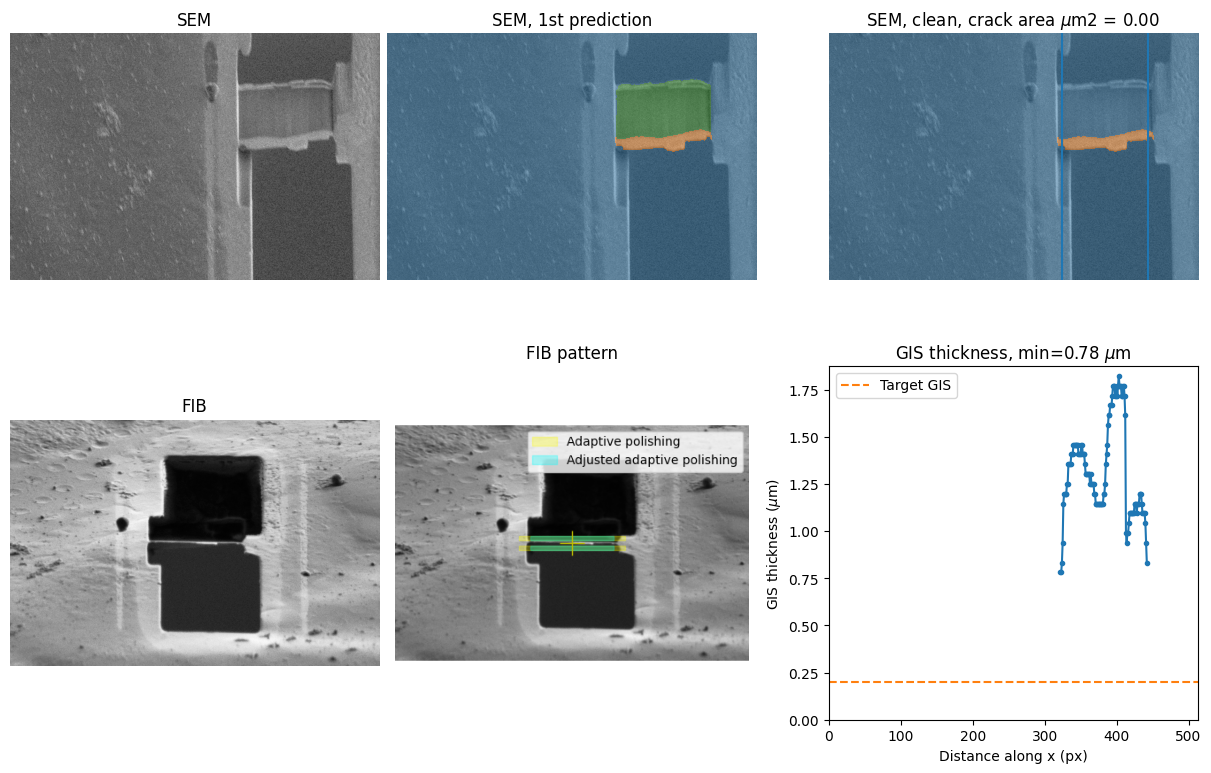

In [7]:
fig[0].gca().axis("off")
fig[0].set_size_inches((4,4))
fig[0].subplots_adjust(left=0, right=1, top=1, bottom=0, wspace=0, hspace=0)
canvas = FigureCanvas(fig[0])
canvas.draw()
width, height = canvas.get_width_height()
image = np.frombuffer(canvas.buffer_rgba(), dtype='uint8').reshape(height, width, 4)

gm.milling_cycle_plot(
    sem_image=eb_image.data,
    first_prediction=prediction,
    clean_prediction=clean_prediction,
    fib_image=ib_image.data,
    gis_thickness_m=gis_thickness_m,
    gis_stop_m=2e-7,
    crack_area_m2=0,
    xlims=xlims,
    fib_screenshot=image,  # need to figure out how to pass this to plot,
    )

plt.gcf().set_constrained_layout(True)